In [1]:
import numpy as np
import h5py
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [7]:
path = "../data/packet-0060070-2025_10_31_15_57_27_CDT.FLOW.hdf5"

In [3]:
def slice_from_ref_region(dset, ref_region_row):
    start = int(ref_region_row["start"])
    stop  = int(ref_region_row["stop"])
    return dset[start:stop]

def get_event_hits_by_event_index(f, event_index):
    hits = f["charge/calib_prompt_hits/data"]
    rr   = f["charge/events/ref/charge/calib_prompt_hits/ref_region"]
    return slice_from_ref_region(hits, rr[event_index])

In [31]:
def get_beam_type(f, evt_idx):
    rr = f["charge/events/ref/light/events/ref_region"]
    light = f["light/events/data"]

    start = int(rr[evt_idx]["start"])
    stop  = int(rr[evt_idx]["stop"])

    if stop <= start:
        return -1

    return int(light[start]["trig_type"]) 

### bad pixels

In [8]:
pixel_seen = {}
pixel_abnormal = {}
MULTIPLICITY_THRESHOLD = 4
with h5py.File(path,"r") as f:
    events = f["charge/events/data"]
    hits = f["charge/calib_prompt_hits/data"]
    rr = f["charge/events/ref/charge/calib_prompt_hits/ref_region"]

    for evt_idx in range(len(events)):

      start = rr[evt_idx]["start"]
      stop  = rr[evt_idx]["stop"]

      hits_ev = hits[start:stop]

      if len(hits_ev) == 0:
          continue

      counts = {}
      for i in range(len(hits_ev)):
        p = (
        int(hits_ev["io_group"][i]),
        int(hits_ev["io_channel"][i]),
        int(hits_ev["chip_id"][i]),
        int(hits_ev["channel_id"][i])
        )
        counts[p] = counts.get(p, 0) + 1

      # update global stats
      for p, n in counts.items():

        # pixel_seen
        pixel_seen[p] = pixel_seen.get(p, 0) + 1

                # abnormal count
        if n > MULTIPLICITY_THRESHOLD:
          pixel_abnormal[p] = pixel_abnormal.get(p, 0) + 1

In [9]:
count_bad = 0

for p in pixel_seen:

    seen = pixel_seen[p]
    abnormal = pixel_abnormal.get(p, 0)

    if seen > 200 and abnormal > 100:
        print(
            "BAD PIXEL:",
            p,
            "| seen =", seen,
            "| abnormal =", abnormal
        )
        count_bad += 1

print("Total bad pixels =", count_bad)

BAD PIXEL: (2, 29, 28, 18) | seen = 19748 | abnormal = 16809
Total bad pixels = 1


### hot region

In [10]:
def find_hot_regions(z, y, hist_range, bins, hot_percentile=99):
    H, z_edges, y_edges = np.histogram2d(z, y, bins=bins, range=hist_range)

    if np.any(H > 0):
        thr = np.percentile(H[H > 0], hot_percentile)
    else:
        thr = np.inf
    hot = (H > thr) 
    visited = np.zeros_like(hot, dtype=bool)
    regions = []
    nz, ny = hot.shape

    for i in range(nz):
        for j in range(ny):
            if not hot[i, j] or visited[i, j]:
                continue

            # flood fill / BFS
            stack = [(i, j)]
            visited[i, j] = True
            cells = []

            while stack:
                x, yy = stack.pop()
                cells.append((x, yy))

                for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
                    xn, yn = x + dx, yy + dy
                    if 0 <= xn < nz and 0 <= yn < ny:
                        if hot[xn, yn] and not visited[xn, yn]:
                            visited[xn, yn] = True
                            stack.append((xn, yn))

            iz = [c[0] for c in cells]
            iy = [c[1] for c in cells]
            
            region = {
                "z_range": (z_edges[min(iz)], z_edges[max(iz) + 1]),
                "y_range": (y_edges[min(iy)], y_edges[max(iy) + 1]),
                "n_bins": len(cells),
                "count_sum": int(sum(H[a, b] for a, b in cells))
            }
            regions.append(region)
    regions = [
        r for r in regions
        if (r["n_bins"] >= 10) or (r["count_sum"] >= 20000)
        ]

    regions.sort(key=lambda r: r["count_sum"], reverse=True)
    return H, z_edges, y_edges, hot, regions


In [34]:
y_1, z_1 = [], []
y_2, z_2 = [], []
with h5py.File(path, "r") as f:
    for evt_idx in range(len(f["charge/events/data"])):
        hits = get_event_hits_by_event_index(f, evt_idx)
        if len(hits) == 0:
            continue
        y = hits['y']
        z = hits['z']
        Q  = hits['Q']  
        mask_1 = np.isfinite(Q) & (Q >= 0) &(z>=-54.32) & (z<=-12.68) & (y>=-51.85) & (y<=51.85) 
        mask_2 = np.isfinite(Q) & (Q >= 0) &(z>=12.68) & (z<=54.32) & (y>=-51.85) & (y<=51.85) 
        if np.any(mask_1):
            y_1.append(y[mask_1])
            z_1.append(z[mask_1])
        if np.any(mask_2):
            y_2.append(y[mask_2])
            z_2.append(z[mask_2])

In [35]:
bins = [94, 234]
range_pos = [[12.68, 54.32], [-51.85, 51.85]]
range_neg = [[-54.32, -12.68], [-51.85, 51.85]]
z_2 = np.concatenate(z_2)
y_2 = np.concatenate(y_2)

z_1 = np.concatenate(z_1)
y_1 = np.concatenate(y_1)
H_pos, z_edges_pos, y_edges_pos, hot_pos, regions_pos = find_hot_regions(
    z_2, y_2, range_pos, bins,
    hot_percentile=99
    
)

H_neg, z_edges_neg, y_edges_neg, hot_neg, regions_neg = find_hot_regions(
    z_1, y_1, range_neg, bins,
    hot_percentile=99
)

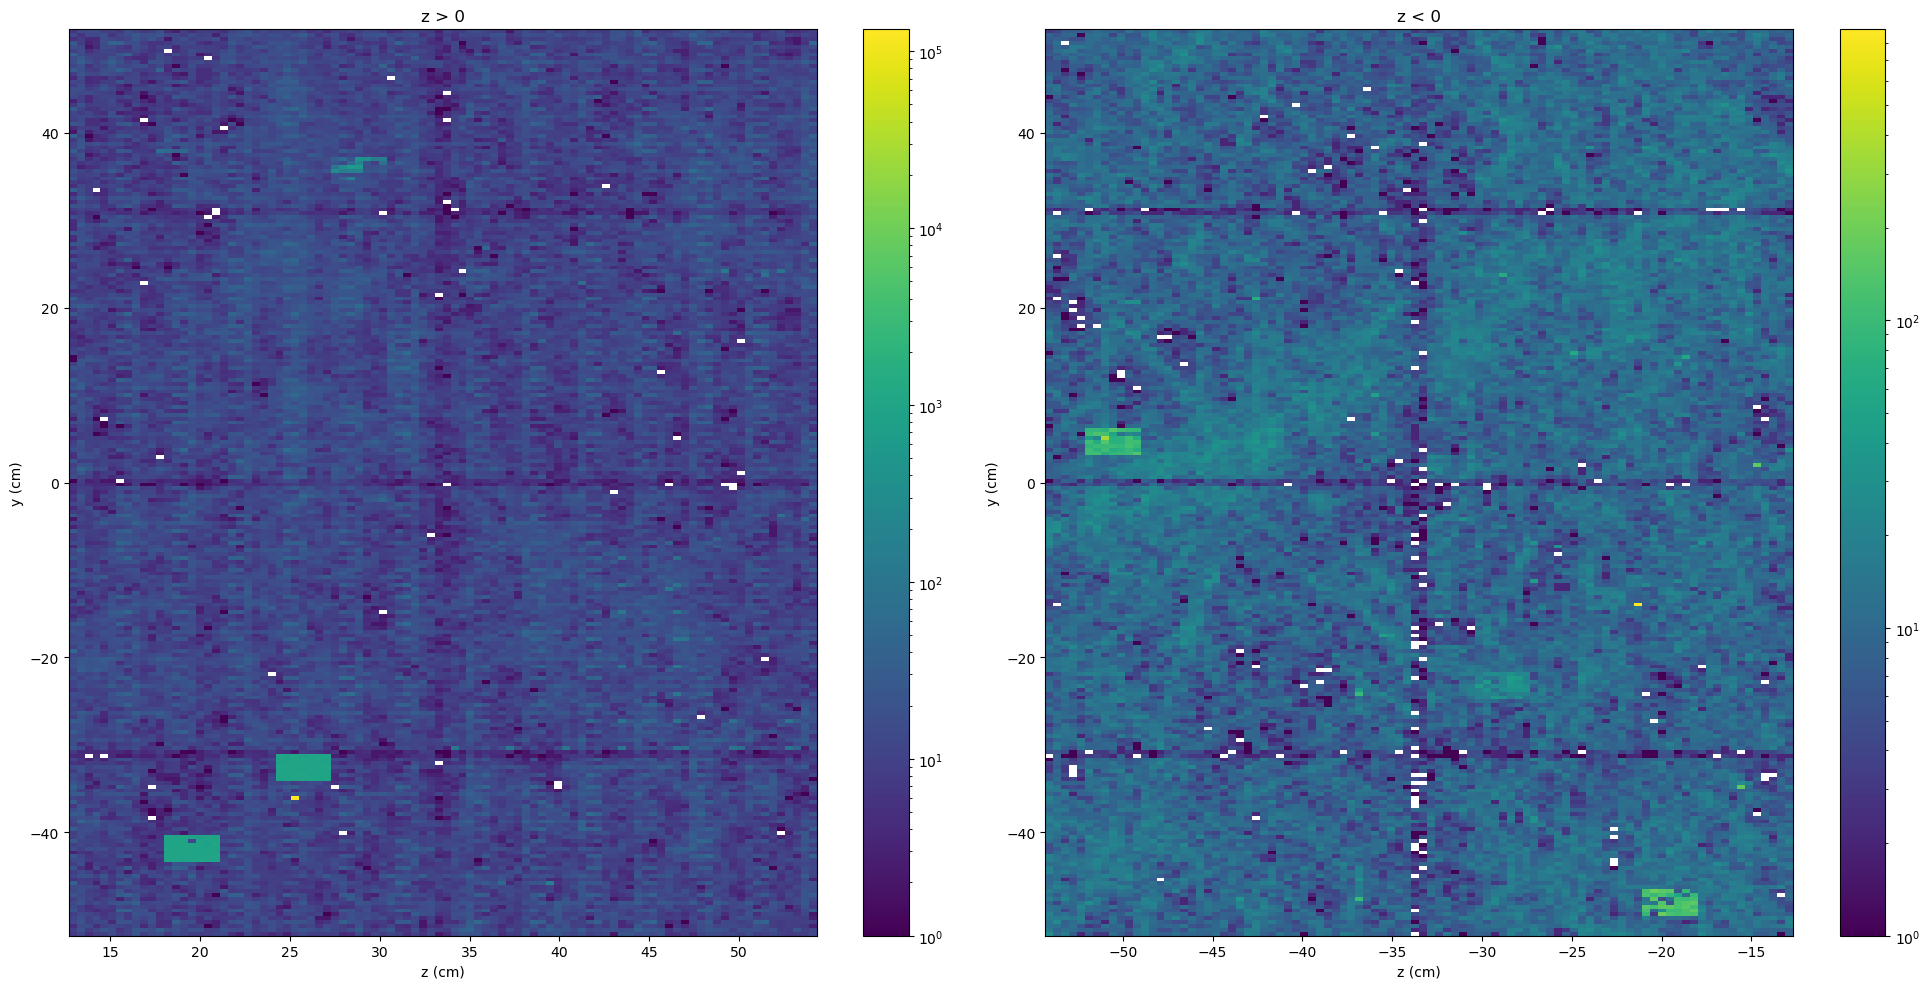

In [36]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10))

# ---- z > 0 ----
h1 = axs[0].hist2d(
    z_2, y_2,
    bins=[94,234],
    range=[[12.68, 54.32], [-51.85, 51.85]],
    norm=LogNorm()
)
plt.colorbar(h1[3], ax=axs[0])
axs[0].set_title("z > 0")
axs[0].set_xlabel("z (cm)")
axs[0].set_ylabel("y (cm)")

# ---- z < 0 ----
h2 = axs[1].hist2d(
    z_1, y_1,
    bins=[94,234],
    range=[[-54.32, -12.68], [-51.85, 51.85]],
    norm=LogNorm()
)
plt.colorbar(h2[3], ax=axs[1])
axs[1].set_title("z < 0")
axs[1].set_xlabel("z (cm)")
axs[1].set_ylabel("y (cm)")

plt.tight_layout()
plt.show()

In [37]:
print("\nHot regions for z > 0:")
for i, r in enumerate(regions_pos, 1):
    print(
        f"{i}: z = [{r['z_range'][0]:.2f}, {r['z_range'][1]:.2f}], "
        f"y = [{r['y_range'][0]:.2f}, {r['y_range'][1]:.2f}], "
        f"n_bins = {r['n_bins']}, count_sum = {r['count_sum']}"
    )

print("\nHot regions for z < 0:")
for i, r in enumerate(regions_neg, 1):
    print(
        f"{i}: z = [{r['z_range'][0]:.2f}, {r['z_range'][1]:.2f}], "
        f"y = [{r['y_range'][0]:.2f}, {r['y_range'][1]:.2f}], "
        f"n_bins = {r['n_bins']}, count_sum = {r['count_sum']}"
    )


Hot regions for z > 0:
1: z = [25.08, 25.53], y = [-36.34, -35.90], n_bins = 1, count_sum = 132951
2: z = [24.20, 27.30], y = [-34.12, -31.02], n_bins = 49, count_sum = 47606
3: z = [18.00, 21.10], y = [-43.43, -40.33], n_bins = 48, count_sum = 47010
4: z = [27.30, 30.40], y = [35.45, 37.23], n_bins = 15, count_sum = 3852

Hot regions for z < 0:
1: z = [-21.10, -18.00], y = [-49.63, -46.53], n_bins = 36, count_sum = 4583
2: z = [-52.11, -49.00], y = [3.10, 6.20], n_bins = 45, count_sum = 4493
3: z = [-28.63, -27.30], y = [-23.93, -21.71], n_bins = 10, count_sum = 343


In [38]:
def remove_regions(z, y, regions):
    keep = np.ones(len(z), dtype=bool)
    for r in regions:
        zmin, zmax = r["z_range"]
        ymin, ymax = r["y_range"]
        inside = (z >= zmin) & (z < zmax) & (y >= ymin) & (y < ymax)
        keep &= ~inside
    return z[keep], y[keep]

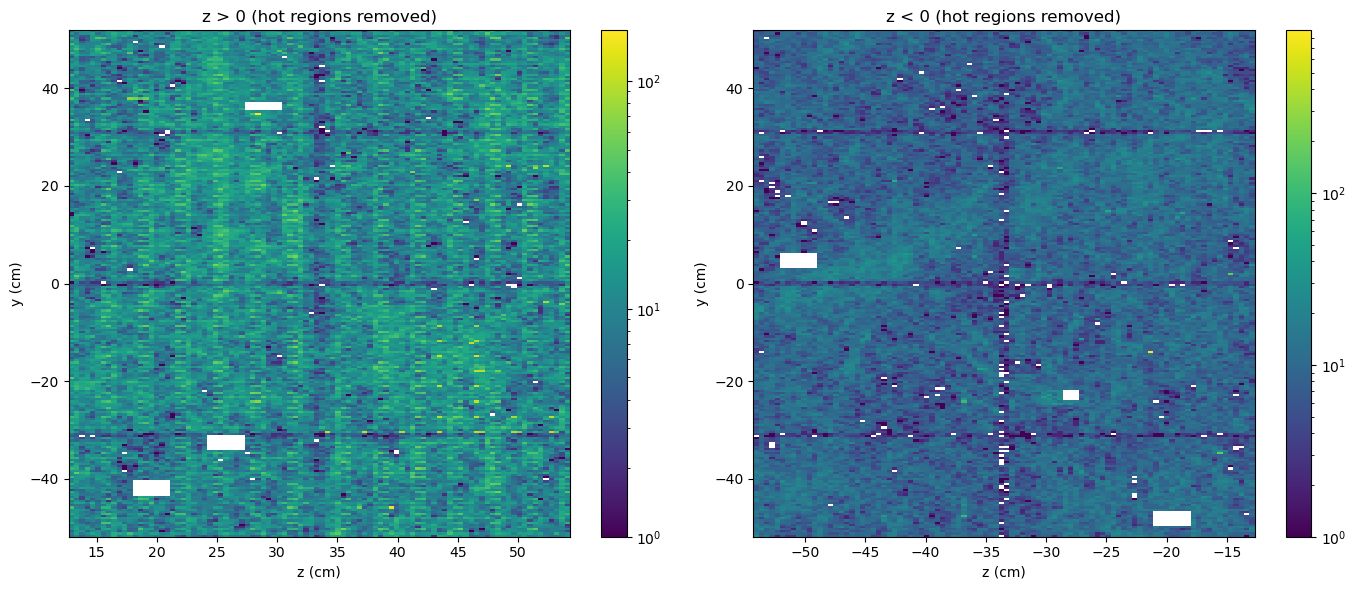

In [39]:
z_pos_clean, y_pos_clean = remove_regions(z_2, y_2, regions_pos)
z_neg_clean, y_neg_clean = remove_regions(z_1, y_1, regions_neg)

# -------------------------
# plot cleaned maps
# -------------------------
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

h1 = axs[0].hist2d(
    z_pos_clean, y_pos_clean,
    bins=bins, range=range_pos, norm=LogNorm()
)
plt.colorbar(h1[3], ax=axs[0])
axs[0].set_title("z > 0 (hot regions removed)")
axs[0].set_xlabel("z (cm)")
axs[0].set_ylabel("y (cm)")

h2 = axs[1].hist2d(
    z_neg_clean, y_neg_clean,
    bins=bins, range=range_neg, norm=LogNorm()
)
plt.colorbar(h2[3], ax=axs[1])
axs[1].set_title("z < 0 (hot regions removed)")
axs[1].set_xlabel("z (cm)")
axs[1].set_ylabel("y (cm)")

plt.tight_layout()
plt.show()

Hot regions for z > 0:
1: z = [25.08, 25.53], y = [-36.34, -35.90], n_bins = 1, count_sum = 132951
2: z = [24.20, 27.30], y = [-34.12, -31.02], n_bins = 49, count_sum = 47606
3: z = [18.00, 21.10], y = [-43.43, -40.33], n_bins = 48, count_sum = 47010
4: z = [27.30, 30.40], y = [35.45, 37.23], n_bins = 15, count_sum = 3852

Hot regions for z < 0:
1: z = [-21.10, -18.00], y = [-49.63, -46.53], n_bins = 36, count_sum = 4583
2: z = [-52.11, -49.00], y = [3.10, 6.20], n_bins = 45, count_sum = 4493
3: z = [-28.63, -27.30], y = [-23.93, -21.71], n_bins = 10, count_sum = 343

In [40]:
hot_regions = [
    {"z_range": [25.08, 25.53], "y_range": [-36.34, -35.90]},
    {"z_range": [24.20, 27.30], "y_range": [-34.12, -31.02]},
    {"z_range": [18.00, 21.10], "y_range": [-43.43, -40.33]},
    {"z_range": [27.30, 30.40], "y_range": [34.45, 37.23]},

    {"z_range": [-21.10, -18.00], "y_range": [-49.63, -46.53]},
    {"z_range": [-52.11, -49.00], "y_range": [3.10, 6.20]},
    {"z_range": [-28.63, -27.30], "y_range": [-23.93, -21.71]},
]
bad_pixels = [(2, 29, 28, 18)]

### fiducal cut and bad pixel cut

In [41]:
def hits_fiducal (hits):
    good = (np.isfinite(hits["x"]) & np.isfinite(hits["y"]) & np.isfinite(hits["z"]) & np.isfinite(hits["Q"]) & (hits["Q"] > 0))
    hits = hits[good]
    # fiducial cut
    y = hits["y"]
    z = hits["z"]
    geom_mask = ((y >= -51.85) & (y <= 51.85) & (
                ((z >= 12.68) & (z <= 54.32)) |
                ((z >= -54.32) & (z <= -12.68))
                ))
    return hits[geom_mask]
def hits_bad_regions(hits, pixels, regions):
    if len(hits) == 0:
        return hits,hits
    # bad pixel mask
    bad_mask = np.zeros(len(hits), dtype=bool)
    for io_group, io_channel, chip_id, channel_id in pixels:
        bad_mask |= (
            (hits["io_group"]   == io_group) &
            (hits["io_channel"] == io_channel) &
            (hits["chip_id"]    == chip_id) &
            (hits["channel_id"] == channel_id)
        )
    # hot region mask
    hot_mask = np.zeros(len(hits), dtype=bool)
    y = hits["y"]
    z = hits["z"]
    for r in regions:
        zmin, zmax = r["z_range"]
        ymin, ymax = r["y_range"]
        hot_mask |= (
            (z >= zmin) & (z < zmax) &
            (y >= ymin) & (y < ymax)
        )
    # combine
    remove_mask = bad_mask | hot_mask
    return hits[~remove_mask],hits[remove_mask]

In [42]:
def repeated_pixel_hits(hits,yz_radius=0.5, x_min=5.0, min_count=3):
    """
    hits when >= min_count hits appear within a small yz region
    (treated as the same pixel region) while being well separated in x.
    """
    n = len(hits)
    if n < min_count:
        return hits, hits[:0]
    remove_mask = np.zeros(n, dtype=bool)
    x = hits["x"]
    y = hits["y"]
    z = hits["z"]

    for i in range(len(hits)):
        dy = y - y[i]
        dz = z - z[i]
        dx = np.abs(x - x[i])

        yz_close = (dy**2 + dz**2) < yz_radius**2
        x_far = dx > x_min

        neighbors = yz_close & x_far
        if np.sum(neighbors) + 1 >= min_count:
            remove_mask[neighbors | (np.arange(n) == i)] = True
    return hits[~remove_mask],hits[remove_mask]

In [43]:
def compute_cluster_features(points):
    center = points.mean(axis=0)
    nhit = len(points)

    dx = points[:, 0].max() - points[:, 0].min()
    dy = points[:, 1].max() - points[:, 1].min()
    dz = points[:, 2].max() - points[:, 2].min()

    if nhit < 2:
        direction_pair = np.array([0.0, 0.0, 1.0], dtype=float)
        pair_length = 0.0
        width_rms = 0.0
        width_max = 0.0
        aspect_ratio = 0.0
        p1 = center.copy()
        p2 = center.copy()
    else:
        diff = points[:, None, :] - points[None, :, :]
        dist = np.linalg.norm(diff, axis=2)

        i, j = np.unravel_index(np.argmax(dist), dist.shape)
        p1 = points[i]
        p2 = points[j]

        vec = p2 - p1
        pair_length = np.linalg.norm(vec)
        direction_pair = vec / (pair_length + 1e-12)

        v = points - p1
        proj_len = v @ direction_pair
        proj_vec = np.outer(proj_len, direction_pair)
        perp_vec = v - proj_vec
        perp_dist = np.linalg.norm(perp_vec, axis=1)

        width_rms = np.sqrt(np.mean(perp_dist**2)) if len(perp_dist) > 0 else 0.0
        width_max = np.max(perp_dist) if len(perp_dist) > 0 else 0.0

        if nhit < 4 or width_rms < 0.05:
            aspect_ratio = 0.0
        else:
            aspect_ratio = pair_length / width_rms

    return {
        "center": center,
        "nhit": int(nhit),
        "dx": float(dx),
        "dy": float(dy),
        "dz": float(dz),
        "pair_length": float(pair_length),
        "direction_pair": direction_pair,
        "width_rms": float(width_rms),
        "width_max": float(width_max),
        "aspect_ratio": float(aspect_ratio),
        "p1": p1,
        "p2": p2,
    }

In [44]:
def classify_cluster(feat):
    L = feat["pair_length"]
    A = feat["aspect_ratio"]

    if L > 10:
        return "track"
    if L > 3 and A >= 3:
        return "track"
    if L > 3 and A < 3:
        return "shower"
    return "normal"

In [45]:
DBSCAN_EPS = 2.     # cm
DBSCAN_MIN_SAMPLES = 1
def run_dbscan(hits):
    coords = np.c_[hits["x"], hits["y"], hits["z"]]
    labels = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES).fit_predict(coords)
    return labels

    
def build_clusters(hits):
    coords = np.c_[hits["x"], hits["y"], hits["z"]]
    labels = run_dbscan(hits)

    clusters = []

    for cid in np.unique(labels):
        if cid == -1:
            continue

        mask = labels == cid

        pts = coords[mask]
        hits_cluster = hits[mask]  

        feat = compute_cluster_features(pts)
        label = classify_cluster(feat)

        clusters.append({
            "cluster_id": int(cid),
            "points": pts,
            "hits": hits_cluster,
            "label": label,
            "center": feat["center"],
            "nhit": feat["nhit"],
            "dx": feat["dx"],
            "dy": feat["dy"],
            "dz": feat["dz"],
            "pair_length": feat["pair_length"],
            "direction_pair": feat["direction_pair"],
            "width_rms": feat["width_rms"],
            "aspect_ratio": feat["aspect_ratio"],
            "p1": feat["p1"],
            "p2": feat["p2"],
        })

    return clusters, labels

In [46]:
def assign_cluster_type(clusters):
    track_idx = 0
    shower_idx = 0
    normal_idx = 0

    for c in clusters:
        if c["label"] == "track":
            c["type"] = f"track_{track_idx}"
            track_idx += 1
        elif c["label"] == "shower":
            c["type"] = f"shower_{shower_idx}"
            shower_idx += 1
        else:
            c["type"] = f"normal_{normal_idx}"
            normal_idx += 1

    return clusters

In [47]:
def remove_clusters_near_track_points(clusters, R_cut=10.0, target_labels=("track", "shower")):
    if len(clusters) == 0:
        keep_clusters = []
        remove_clusters = []
        min_dists = np.array([], dtype=float)
        keep_mask = np.array([], dtype=bool)
        remove_mask = np.array([], dtype=bool)
        return keep_clusters, remove_clusters
    ref_points_list = []
    for c in clusters:
        if c["label"] in target_labels and len(c["points"]) > 0:
            ref_points_list.append(c["points"])

    if len(ref_points_list) == 0:
        keep_clusters = clusters[:]
        remove_clusters = []
        keep_mask = np.ones(len(clusters), dtype=bool)
        remove_mask = ~keep_mask
        min_dists = np.full(len(clusters), np.inf, dtype=float)
        return keep_clusters, remove_clusters

    ref_points = np.vstack(ref_points_list)   # (M,3)

    keep_mask = np.ones(len(clusters), dtype=bool)
    min_dists = np.full(len(clusters), np.inf, dtype=float)

    for i, c in enumerate(clusters):
        pts = c["points"]
        if len(pts) == 0:
            min_dists[i] = np.inf
            continue

        diff = pts[:, None, :] - ref_points[None, :, :]
        dist = np.linalg.norm(diff, axis=2)
        min_d = dist.min()

        min_dists[i] = min_d

        if c["label"] in target_labels:
            keep_mask[i] = True
        else:
            keep_mask[i] = (min_d >= R_cut)

    remove_mask = ~keep_mask

    keep_clusters = [c for i, c in enumerate(clusters) if keep_mask[i]]
    remove_clusters = [c for i, c in enumerate(clusters) if remove_mask[i]]

    return keep_clusters, remove_clusters

In [48]:
all_clusters = []
bad_region_hits = []
repeat_pixels=[]

with h5py.File(path, "r") as f:
#    n_events = 400
#    for evt_idx in range(n_events):
    print(len(f["charge/events/data"]))
    for evt_idx in range(len(f["charge/events/data"])):
#        beam_type = get_beam_type(f, evt_idx)
        hits = get_event_hits_by_event_index(f, evt_idx)
        #fiducal cut
        hits = hits_fiducal (hits)
     #  print(len(hits))
     # hits of bad region
        if len(hits) == 0:
            continue
        hits,bad_region = hits_bad_regions(hits, bad_pixels, hot_regions)
        if len(bad_region) > 0:
            bad_region_hits.append({"evt_idx": evt_idx,"hits": bad_region})
    #print(len(hits))
    # hits of repeat pixels
        if len(hits)==0:
            continue
        hits,repeat_pixel = repeated_pixel_hits(hits,yz_radius=0.5, x_min=5.0, min_count=3)
        if len(repeat_pixel) > 0:
            repeat_pixels.append({"evt_idx": evt_idx,"hits": repeat_pixel})
    #print(len(hits))
        if len(hits)== 0:
            continue
        
            #dbscan and label track and shower
        clusters, labels = build_clusters(hits)

        clusters_keep,clusters_remove = remove_clusters_near_track_points(clusters,R_cut=15.0, target_labels=("track", "shower"))
        if len(clusters_keep) > 10:
            for c in clusters_keep:
                c["type"] = "removed"
            for c in clusters_remove:
                c["type"] = "removed"
            clusters_final = clusters_keep + clusters_remove
        else:
            clusters_keep = assign_cluster_type(clusters_keep)
            for c in clusters_remove:
                c["type"] = "removed"
            clusters_final = clusters_keep + clusters_remove
           
        for c in clusters_final:
            c["evt_idx"] = evt_idx
 #           c["beam_type"] = beam_type
            all_clusters.append(c)
        

21826


In [49]:
from collections import defaultdict

bad_map = {}
for x in bad_region_hits:
    bad_map[x["evt_idx"]] = x["hits"]

rep_map = {}
for x in repeat_pixels:
    rep_map[x["evt_idx"]] = x["hits"]

cluster_map = defaultdict(list)
for c in all_clusters:
    cluster_map[c["evt_idx"]].append(c)

In [50]:
def plot_event(evt_idx, view="3d"):

    if view == "3d":
        fig = plt.figure(figsize=(9, 8))
        ax = fig.add_subplot(111, projection="3d")
    else:
        fig, ax = plt.subplots(figsize=(7, 7))

    used_labels = set()

    def add_label(label):
        if label in used_labels:
            return None
        used_labels.add(label)
        return label

    def scatter_points(points, color, label, size=15):
        points = np.asarray(points)

        if len(points) == 0:
            return

        if view == "3d":
            ax.scatter(
                points[:, 0], points[:, 1], points[:, 2],
                c=color,
                s=size,
                label=add_label(label)
            )
        else:
            ax.scatter(
                points[:, 2], points[:, 1],
                c=color,
                s=size,
                label=add_label(label)
            )

    # bad region hits
    if evt_idx in bad_map:
        hits = bad_map[evt_idx]
        pts = np.c_[hits["x"], hits["y"], hits["z"]]
        scatter_points(pts, "green", "bad region", size=25)

    # repeated pixel hits
    if evt_idx in rep_map:
        hits = rep_map[evt_idx]
        pts = np.c_[hits["x"], hits["y"], hits["z"]]
        scatter_points(pts, "purple", "repeat pixel", size=25)

    # clusters
    for c in cluster_map[evt_idx]:

        pts = c["points"]

        if c.get("type") == "removed":
            scatter_points(pts, "black", "removed", size=15)

        elif c.get("label") == "track":
            scatter_points(pts, "red", "track", size=18)

        elif c.get("label") == "shower":
            scatter_points(pts, "orange", "shower", size=18)

        else:
            scatter_points(pts, "blue", "normal", size=12)

    if view == "3d":
        ax.set_xlabel("x [cm]")
        ax.set_ylabel("y [cm]")
        ax.set_zlabel("z [cm]")
        ax.set_xlim(-53.93, 53.93)
        ax.set_ylim(-51.85, 51.85)
        ax.set_zlim(-54.32, 54.32)
    else:
        ax.set_xlabel("z [cm]")
        ax.set_ylabel("y [cm]")
        ax.set_ylim(-51.85, 51.85)
        ax.set_zlim(-54.32, 54.32)

    ax.set_title(f"Event {evt_idx}")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [38]:
c = cluster_map[0][0]
type(c["points"]), np.asarray(c["points"]).shape, np.asarray(c["points"]).dtype

(numpy.ndarray, (1, 3), dtype('float64'))

In [39]:
for c in cluster_map[0][:5]:
    print(np.asarray(c["points"]).shape)

(1, 3)
(1, 3)


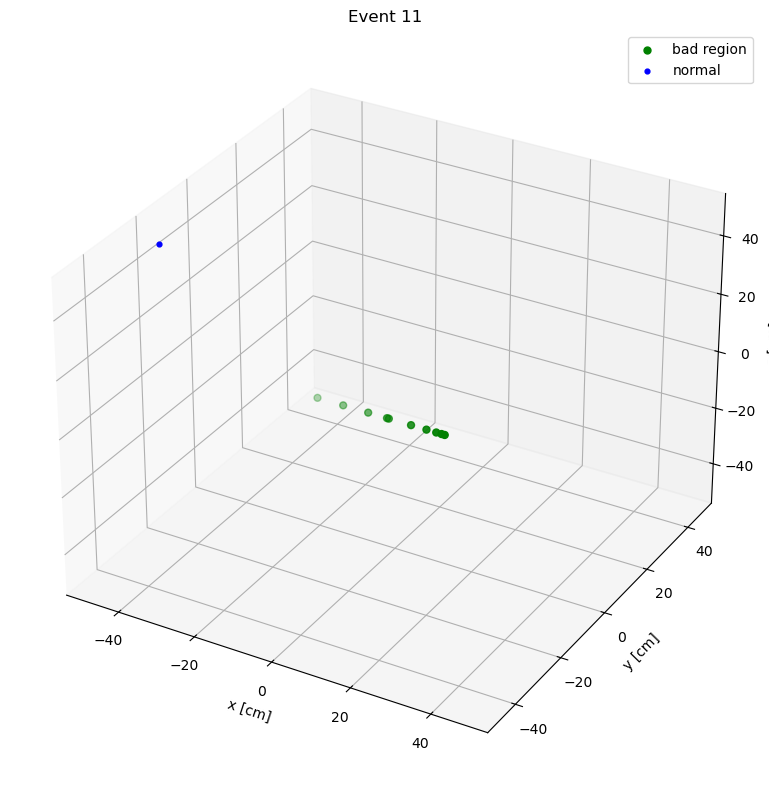

In [53]:
plot_event(11, view="3d")

In [53]:
normal_energy = np.array([
    c["Qsum"]
    for c in all_clusters
    if c.get("label") == "normal" and c.get("type") != "removed"
])

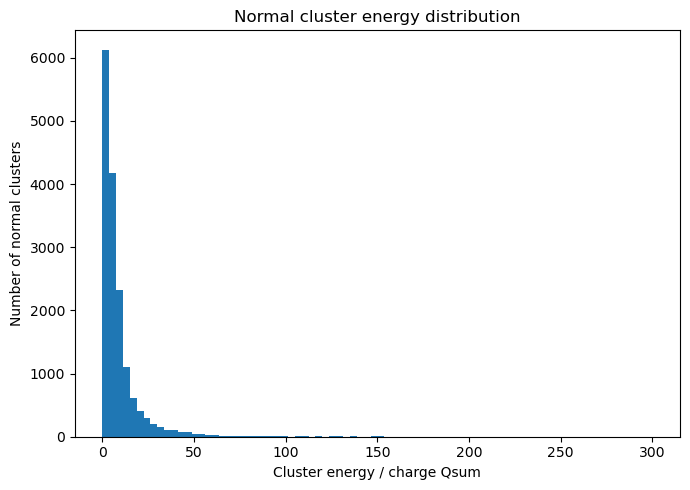

In [59]:
plt.figure(figsize=(7,5))

plt.hist(
    normal_energy,
    bins=80,
    range=(0, 300)
)

plt.xlabel("Cluster energy / charge Qsum")
plt.ylabel("Number of normal clusters")
plt.title("Normal cluster energy distribution")
plt.tight_layout()
#plt.yscale("log")
plt.show()

In [33]:
event_hits = defaultdict(list)
for c in all_clusters:

    if c.get("label") != "normal":
        continue

    if c.get("type") == "removed":
        continue

    evt_idx = c["evt_idx"]
    hits = c["hits"]

    arr = np.zeros(len(hits), dtype=[
        ("evt_index",   "i4"),
        ("cluster_id",  "i4"),
        ("beam_type",   "i1"),
        ("x",           "f4"),
        ("y",           "f4"),
        ("z",           "f4"),
        ("Q",           "f4"),
        ("io_group",    "i4"),
        ("io_channel",  "i4"),
        ("chip_id",     "i4"),
        ("channel_id",  "i4"),
    ])

    arr["evt_index"]  = evt_idx
    arr["cluster_id"] = c["cluster_id"]
    arr["beam_type"]  = c["beam_type"]

    arr["x"] = hits["x"]
    arr["y"] = hits["y"]
    arr["z"] = hits["z"]
    arr["Q"] = hits["Q"]
    arr["io_group"] = hits["io_group"]
    arr["io_channel"] = hits["io_channel"]
    arr["chip_id"] = hits["chip_id"]
    arr["channel_id"] = hits["channel_id"]

    event_hits[evt_idx].append(arr)

In [35]:
out_path = "data/normal_hits_by_event.h5"

with h5py.File(out_path, "w") as f:

    for evt_idx, arrs in event_hits.items():

        hits_evt = np.concatenate(arrs)

        f.create_dataset(f"event_{evt_idx:06d}", data=hits_evt)

In [30]:
with h5py.File(path, "r") as f:
    rr = f["charge/events/ref/light/events/ref_region"]

    count = 0
    for evt_idx in range(len(rr)):
        start = int(rr[evt_idx]["start"])
        stop  = int(rr[evt_idx]["stop"])

        if stop > start:
            light_evt = f["light/events/data"][start:stop]
            print(evt_idx, "light index", start, stop, "trig_type", light_evt["trig_type"])
            count += 1

            if count >= 20:
                break

37 light index 0 1 trig_type [0]
38 light index 1 2 trig_type [0]
39 light index 2 3 trig_type [0]
41 light index 3 4 trig_type [1]
42 light index 4 5 trig_type [0]
43 light index 5 6 trig_type [0]
44 light index 6 7 trig_type [0]
45 light index 7 8 trig_type [0]
46 light index 8 9 trig_type [0]
47 light index 9 10 trig_type [0]
48 light index 10 11 trig_type [0]
50 light index 11 12 trig_type [0]
51 light index 12 13 trig_type [0]
53 light index 13 14 trig_type [0]
54 light index 14 15 trig_type [0]
55 light index 15 16 trig_type [0]
56 light index 16 17 trig_type [0]
57 light index 17 18 trig_type [0]
58 light index 18 19 trig_type [0]
59 light index 19 20 trig_type [1]


In [58]:
out_path = "../data/normal_hits_ref_region.h5"
# ============================================================
# dtype
# ============================================================

hit_dtype = np.dtype([
    ("evt_index",   "i4"),
    ("cluster_id",  "i4"),
    ("x",           "f4"),
    ("y",           "f4"),
    ("z",           "f4"),
    ("Q",           "f4"),
    ("io_group",    "i4"),
    ("io_channel",  "i4"),
    ("chip_id",     "i4"),
    ("channel_id",  "i4"),
])

ref_region_dtype = np.dtype([
    ("start", "i8"),
    ("stop",  "i8"),
])

# ============================================================
# collect normal hits by event
# ============================================================

event_hits = defaultdict(list)

for c in all_clusters:

    if c.get("label") != "normal":
        continue

    if c.get("type") == "removed":
        continue

    hits = c["hits"]

    if len(hits) == 0:
        continue

    arr = np.zeros(len(hits), dtype=hit_dtype)

    arr["evt_index"]  = c["evt_idx"]
    arr["cluster_id"] = c["cluster_id"]

    arr["x"] = hits["x"]
    arr["y"] = hits["y"]
    arr["z"] = hits["z"]
    arr["Q"] = hits["Q"]

    arr["io_group"]   = hits["io_group"]
    arr["io_channel"] = hits["io_channel"]
    arr["chip_id"]    = hits["chip_id"]
    arr["channel_id"] = hits["channel_id"]

    event_hits[c["evt_idx"]].append(arr)

# ============================================================
# build data + ref_region
# ============================================================

all_hits = []
ref_regions = []

start = 0

for evt_idx in range(n_events):

    if len(event_hits[evt_idx]) > 0:

        hits_evt = np.concatenate(event_hits[evt_idx])

        stop = start + len(hits_evt)

        all_hits.append(hits_evt)

    else:
        # empty event
        stop = start

    ref_regions.append((start, stop))

    start = stop

# ============================================================
# concatenate
# ============================================================

if len(all_hits) > 0:
    all_hits = np.concatenate(all_hits)
else:
    all_hits = np.zeros(0, dtype=hit_dtype)

ref_regions = np.array(
    ref_regions,
    dtype=ref_region_dtype
)

# ============================================================
# save
# ============================================================

with h5py.File(out_path, "w") as f:

    f.create_dataset(
        "normal_hits/data",
        data=all_hits
    )

    f.create_dataset(
        "normal_hits/ref_region",
        data=ref_regions
    )

print("saved:", out_path)
print("total events:", n_events)
print("events with normal hits:", len(event_hits))
print("total normal hits:", len(all_hits))

saved: ../data/normal_hits_ref_region.h5
total events: 21826
events with normal hits: 21826
total normal hits: 41082


In [57]:
with h5py.File(path, "r") as f:
    n_events = len(f["charge/events/data"])

In [59]:
empty_count = np.sum(
    ref_regions["start"] == ref_regions["stop"]
)

print(empty_count)

7152
